In [20]:
## Loading Data Set

import pandas as pd

data = pd.read_csv("C:/Users/HP 640 G2/Desktop/generator_data.csv")
print(data.head())

       Date  Load_kW  Temperature_C  Vibration  Downtime
0  1/1/2024   524.84          85.15       6.05         1
1  1/2/2024   493.09          86.78       7.55         1
2  1/3/2024   532.38          90.96       8.45         1
3  1/4/2024   576.15          78.43       5.07         0
4  1/5/2024   488.29          58.98       4.32         0


In [21]:
## Understanding The Data Set
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           200 non-null    object 
 1   Load_kW        200 non-null    float64
 2   Temperature_C  200 non-null    float64
 3   Vibration      200 non-null    float64
 4   Downtime       200 non-null    int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 7.9+ KB
None


In [33]:
print(data.describe())

          Load_kW  Temperature_C  Vibration    Downtime
count  200.000000     200.000000  200.00000  200.000000
mean   497.961350      72.378150    5.26450    0.220000
std     46.550059       9.483713    1.84159    0.415286
min    369.010000      44.070000    1.29000    0.000000
25%    464.745000      65.715000    4.02000    0.000000
50%    499.795000      71.610000    5.07000    0.000000
75%    525.045000      77.232500    6.16500    0.000000
max    636.010000     103.920000   11.68000    1.000000


# Checking The Behaviors of the Parameter through Plots

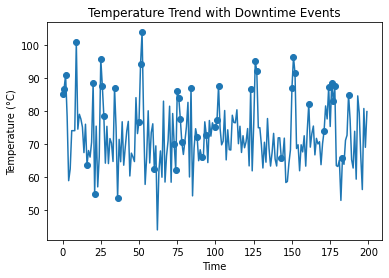

In [29]:
import matplotlib.pyplot as plt

# Temperature Trends

plt.figure()
plt.plot(data['Temperature_C'])

# Highlight downtime points
downtime_points = data[data['Downtime'] == 1]

plt.scatter(downtime_points.index, downtime_points['Temperature_C'])

plt.title('Temperature Trend with Downtime Events')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.show()

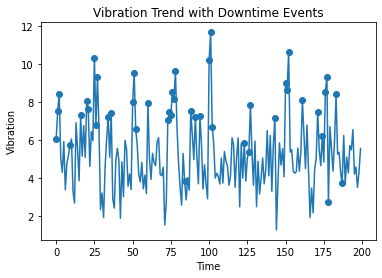

In [32]:
# Vibration Trends

plt.figure()
plt.plot(data['Vibration'])

downtime_points = data[data['Downtime'] == 1]

plt.scatter(downtime_points.index, downtime_points['Vibration'])

plt.title('Vibration Trend with Downtime Events')
plt.xlabel('Time')
plt.ylabel('Vibration')
plt.show()

In [25]:
# Detecting Risk Conditions

high_temp = data[data['Temperature_C'] > 85]
print(high_temp)

          Date  Load_kW  Temperature_C  Vibration  Downtime
0     1/1/2024   524.84          85.15       6.05         1
1     1/2/2024   493.09          86.78       7.55         1
2     1/3/2024   532.38          90.96       8.45         1
9    1/10/2024   527.13         100.82       5.77         1
20   1/21/2024   573.28          88.52       8.09         1
25   1/26/2024   505.55          95.91      10.34         1
26   1/27/2024   442.45          87.71       6.83         1
34    2/4/2024   541.13          87.15       7.25         1
51   2/21/2024   480.75          94.28       9.52         1
52   2/22/2024   466.15         103.92       6.61         1
75   3/16/2024   541.10          86.21       7.32         1
84   3/25/2024   459.58          87.06       3.87         1
102  4/12/2024   482.86          87.79       6.72         1
123   5/3/2024   429.91          86.74       5.86         1
126   5/6/2024   450.47          95.10       5.36         1
127   5/7/2024   471.69          92.17  

The analysis of high-temperature conditions above reveals a strong and consistent relationship between elevated temperature levels and system downtime. All observations exceeding the 85°C threshold correspond to failure events, indicating that temperature is a critical predictor of generator instability. This suggests that implementing real-time monitoring and threshold-based alerts can significantly reduce unexpected downtime and improve operational reliability.

In [26]:
#This simulates fault detection

high_vibration = data[data['Vibration'] > 7]
print(high_vibration)

          Date  Load_kW  Temperature_C  Vibration  Downtime
1     1/2/2024   493.09          86.78       7.55         1
2     1/3/2024   532.38          90.96       8.45         1
16   1/17/2024   449.36          63.82       7.33         1
20   1/21/2024   573.28          88.52       8.09         1
21   1/22/2024   488.71          55.06       7.63         1
25   1/26/2024   505.55          95.91      10.34         1
27   1/28/2024   518.78          78.58       9.31         1
34    2/4/2024   541.13          87.15       7.25         1
36    2/6/2024   510.44          53.80       7.44         1
50   2/20/2024   516.20          76.85       7.99         1
51   2/21/2024   480.75          94.28       9.52         1
60    3/1/2024   476.04          62.58       7.95         1
73   3/14/2024   578.23          70.08       7.05         1
74   3/15/2024   369.01          62.15       7.47         1
75   3/16/2024   541.10          86.21       7.32         1
76   3/17/2024   504.35          84.11  

# Visualization for Generator Risk Condition

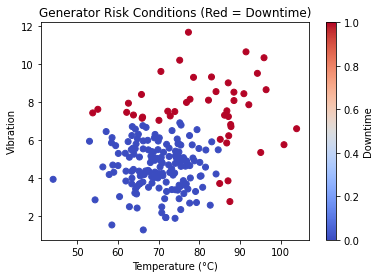

In [35]:
import matplotlib.pyplot as plt

plt.scatter(data['Temperature_C'], data['Vibration'], c=data['Downtime'], cmap='coolwarm')
plt.xlabel('Temperature (°C)')
plt.ylabel('Vibration')
plt.title('Generator Risk Conditions (Red = Downtime)')
plt.colorbar(label='Downtime')
plt.show()

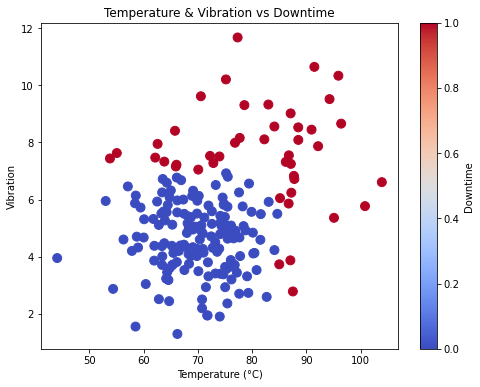

In [36]:
plt.figure(figsize=(8,6))
plt.scatter(data['Temperature_C'], data['Vibration'], c=data['Downtime'], cmap='coolwarm', s=80)
plt.xlabel('Temperature (°C)')
plt.ylabel('Vibration')
plt.title('Temperature & Vibration vs Downtime')
plt.colorbar(label='Downtime')
plt.show()

# Correlation Analysis

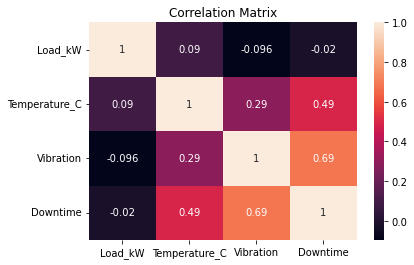

In [34]:
import seaborn as sns

sns.heatmap(data.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

#This shows: How temperature, vibration, and load relate to downtime